<a href="https://colab.research.google.com/github/DakshL9/Compute_01-02/blob/main/Compute_ML_Task01_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Fetch

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/bank-additional-full.csv",
    sep=";"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Data Explore

In [ ]:
df.shape

(41188, 21)

In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
df.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [ ]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


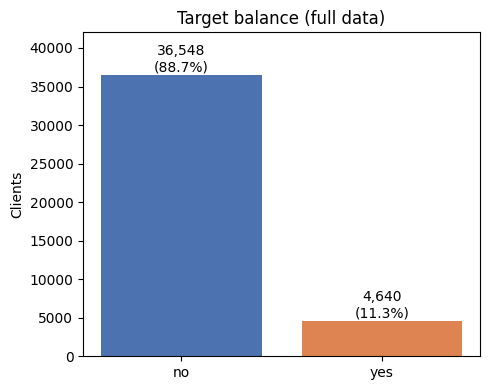

In [ ]:
counts = df['y'].value_counts()
pct = counts / len(df) * 100

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(counts.index, counts.values, color=['#4C72B0', '#DD8452'])
for i, (c, p) in enumerate(zip(counts.values, pct.values)):
    ax.text(i, c, f"{c:,}\n({p:.1f}%)", ha='center', va='bottom')
ax.set_title("Target balance (full data)")
ax.set_ylabel("Clients")
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()

# Null & Duplicates

In [ ]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [ ]:
df.duplicated().sum()  # Keep as there can exist data with same states

np.int64(12)

In [ ]:
print((df['pdays'] == 999).sum()) #missing values the site says that exist but are =-1

df["previously_contacted"] = (df["pdays"] != 999) # creation of binary category for easier understanding

39673


In [ ]:
df['poutcome']=df['poutcome'].fillna(value='nonexistent') #previously not contacted at all
df['contact']=df['contact'].fillna(value='unknown') # Not entered? Investigate later.
df['job']=df['job'].fillna(value='unknown') # As mentioned in variables table
df['education']=df['education'].fillna(value='unknown') # As mentioned in variables table

In [ ]:
# Segregation of cols into num/cat

numerical_cols = ['age', 'previous', 'emp.var.rate', 'cons.price.idx',
                    'cons.conf.idx', 'euribor3m', 'nr.employed']
categorical_cols = ['job', 'marital', 'education', 'contact', 'day_of_week', 'month', 'poutcome', ]
binary_cols = [ 'default', 'housing', 'loan', 'previously_contacted']
cols = numerical_cols + categorical_cols + binary_cols
target_var = 'y'

# 'duration' dropped as known post-call
# 'campaign' does not necessarily affect the client's choice to subscribe
# 'pdays' unnecessary as it is replaced by 'previously_contacted'

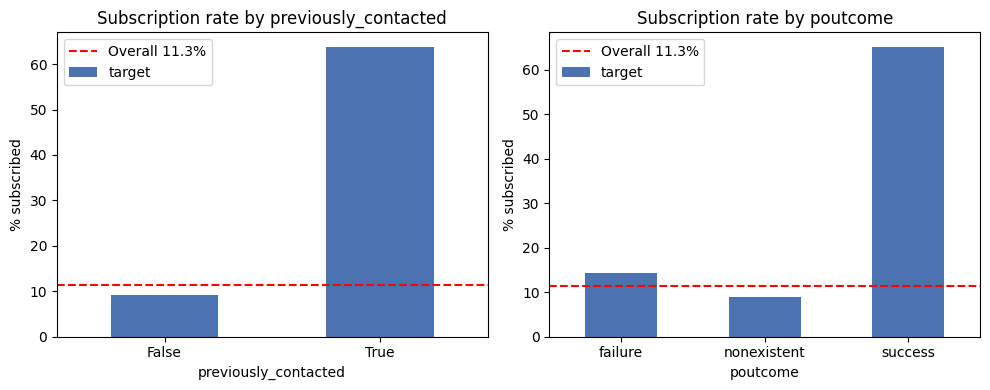

In [ ]:
tmp = df.assign(target=(df['y'] == 'yes').astype(int))
overall = tmp['target'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, ['previously_contacted', 'poutcome']):
    rate = tmp.groupby(col)['target'].mean() * 100
    rate.plot(kind='bar', ax=ax, color='#4C72B0')
    ax.axhline(overall, color='red', ls='--', label=f'Overall {overall:.1f}%')
    ax.set_title(f"Subscription rate by {col}")
    ax.set_ylabel("% subscribed")
    ax.tick_params(axis='x', rotation=0)
    ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
df['y'] = df['y'].map({"yes": 1, "no": 0})

df['y'].tail(3)

,y
41185,0
41186,1
41187,0


#Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split


split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
hold_df  = df.iloc[split_idx:]

X_train, X_test, y_train, y_test = train_df[cols], hold_df[cols], train_df[target_var], hold_df[target_var]

print(f"Training data:\nX_train: {X_train.shape}\ny_train: {y_train.shape}\n\nFinal holdout data:\nX_holdout: {X_test.shape}\ny_holdout: {y_test.shape}\n\nTraining subscription rate:\n{y_train.mean() * 100:.2f}%\n\nHoldout subscription rate:\n{y_test.mean() * 100:.2f}%")

Training data:
X_train: (32950, 18)
y_train: (32950,)

Final holdout data:
X_holdout: (8238, 18)
y_holdout: (8238,)

Training subscription rate:
6.37%

Holdout subscription rate:
30.83%


#Standardization & Encoding

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

col_transform = ColumnTransformer([
    ("bin", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False), binary_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
    ("num", StandardScaler(), numerical_cols),
])

X_train_p = col_transform.fit_transform(X_train)
X_test_p  = col_transform.transform(X_test)

X_train_p = pd.DataFrame(X_train_p)
X_test_p = pd.DataFrame(X_test_p)

X_train_p.head(), X_test_p.head(), y_train, y_test

(    0    1    2    3    4    5    6    7    8    9   ...   50   51   52  \
 0  1.0  0.0  0.0  1.0  0.0  0.0  1.0  0.0  0.0  0.0  ...  0.0  1.0  0.0   
 1  0.0  1.0  0.0  1.0  0.0  0.0  1.0  0.0  0.0  0.0  ...  0.0  1.0  0.0   
 2  1.0  0.0  0.0  0.0  0.0  1.0  1.0  0.0  0.0  0.0  ...  0.0  1.0  0.0   
 3  1.0  0.0  0.0  1.0  0.0  0.0  1.0  0.0  0.0  0.0  ...  0.0  1.0  0.0   
 4  1.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  1.0  0.0  ...  0.0  1.0  0.0   
 
          53       54        55        56        57        58        59  
 0  1.707657 -0.26539  0.387561  0.603053  1.095924  0.458022 -0.092304  
 1  1.814563 -0.26539  0.387561  0.603053  1.095924  0.458022 -0.092304  
 2 -0.323561 -0.26539  0.387561  0.603053  1.095924  0.458022 -0.092304  
 3 -0.002842 -0.26539  0.387561  0.603053  1.095924  0.458022 -0.092304  
 4  1.707657 -0.26539  0.387561  0.603053  1.095924  0.458022 -0.092304  
 
 [5 rows x 60 columns],
     0    1    2    3    4    5    6    7    8    9   ...   50   51   52

#Model Fitting

##Dummy Classifier (Baseline)

In [ ]:
from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score,
                             classification_report, confusion_matrix,)

dummy=DummyClassifier(strategy='prior')
dummy.fit(X_train_p, y_train)

y_pred_dummy = dummy.predict(X_test_p)
probab_dummy = dummy.predict_proba(X_test_p)

print("Accuracy:", (accuracy_score(y_test, y_pred_dummy)*100))

print("\nPrecision:", (precision_score(y_test, y_pred_dummy, zero_division=0)*100))

print("\nRecall:", (recall_score(y_test, y_pred_dummy, zero_division=0)*100))

print("\nF1 Score:", (f1_score(y_test, y_pred_dummy, zero_division=0)*100))

print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred_dummy))


print("\nClassification Report:\n", classification_report(y_test, y_pred_dummy, zero_division=0))




Accuracy: 69.16727361009953

Precision: 0.0

Recall: 0.0

F1 Score: 0.0
Confusion Matrix: 
 [[5698    0]
 [2540    0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.69      1.00      0.82      5698
           1       0.00      0.00      0.00      2540

    accuracy                           0.69      8238
   macro avg       0.35      0.50      0.41      8238
weighted avg       0.48      0.69      0.57      8238



##Logistic Regression

Logistic Regression is a binary classification method which uses the sigmoid function to classify the data points

max_iter = n, max iterations allowed to achieve convergence

class_weight = 'balanced'/none/custom -> to add weights since yes is a minority

In [ ]:
logi=LogisticRegression(max_iter=2000, class_weight="balanced")

logi.fit(X_train_p, y_train)

y_pred_logi = logi.predict(X_test_p)
probab_logi = logi.predict_proba(X_test_p)

print("Accuracy:", (accuracy_score(y_test, y_pred_logi)*100))

print("\nPrecision:", (precision_score(y_test, y_pred_logi, zero_division=0)*100))

print("\nRecall:", (recall_score(y_test, y_pred_logi, zero_division=0)*100))

print("\nF1 Score:", f1_score(y_test, y_pred_logi, zero_division=0))

print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred_logi))


print("\nClassification Report:\n", classification_report(y_test, y_pred_logi, zero_division=0))

Accuracy: 48.57975236707939

Precision: 35.578231292517

Recall: 82.36220472440945

F1 Score: 0.4969121140142518
Confusion Matrix: 
 [[1910 3788]
 [ 448 2092]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.34      0.47      5698
           1       0.36      0.82      0.50      2540

    accuracy                           0.49      8238
   macro avg       0.58      0.58      0.49      8238
weighted avg       0.67      0.49      0.48      8238



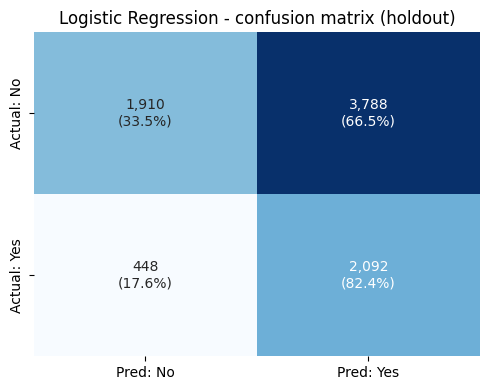

In [ ]:
from sklearn.metrics import confusion_matrix

model_name = "Logistic Regression"   # change the title here
y_pred = ...                         # put your predicted labels here

cm = confusion_matrix(y_test, y_pred_logi)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100   # % of each true class

labels = np.array([[f"{cm[i, j]:,}\n({cm_pct[i, j]:.1f}%)" for j in range(2)]
                   for i in range(2)])

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Pred: No', 'Pred: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])
plt.title(f"{model_name} - confusion matrix (holdout)")
plt.tight_layout()
plt.show()

##Decision Tree


In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_p, y_train)

y_pred_dt = dt_model.predict(X_test_p)

print("Accuracy:", (accuracy_score(y_test, y_pred_dt)*100))

print("\nPrecision:", (precision_score(y_test, y_pred_dt, zero_division=0)*100))

print("\nRecall:", (recall_score(y_test, y_pred_dt, zero_division=0)*100))

print("\nF1 Score:", (f1_score(y_test, y_pred_dt, zero_division=0)*100))

print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred_dt))


print("\nClassification Report:\n", classification_report(y_test, y_pred_dt, zero_division=0))


Accuracy: 67.35858218014081

Precision: 45.53089382123575

Recall: 29.88188976377953

F1 Score: 36.08271927739482
Confusion Matrix: 
 [[4790  908]
 [1781  759]]

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.84      0.78      5698
           1       0.46      0.30      0.36      2540

    accuracy                           0.67      8238
   macro avg       0.59      0.57      0.57      8238
weighted avg       0.64      0.67      0.65      8238



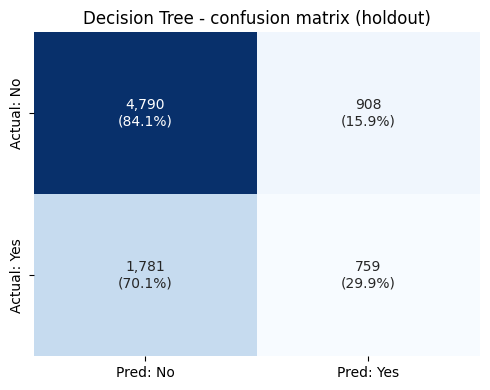

In [ ]:
from sklearn.metrics import confusion_matrix

model_name = "Decision Tree"   # change the title here
y_pred = ...                         # put your predicted labels here

cm = confusion_matrix(y_test, y_pred_dt)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100   # % of each true class

labels = np.array([[f"{cm[i, j]:,}\n({cm_pct[i, j]:.1f}%)" for j in range(2)]
                   for i in range(2)])

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Pred: No', 'Pred: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])
plt.title(f"{model_name} - confusion matrix (holdout)")
plt.tight_layout()
plt.show()

## Random Forest (Bagging Method)

Trains on multiple decisions trees running parallel with different subsets and depth to ensure least overfitting

n_estimators: The number of trees in the forest. Higher values generally lead to better performance but increase training time.

class_weight: Adjusts the weights of the minority class to handle class imbalance. 'balanced' automatically adjusts weights inversely proportional to class frequencies.

random_state: Setting it to a fixed value ensures reproducibility.

n_jobs: The number of CPU cores to use for parallel processing. -1 uses all available cores.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=5, max_features="sqrt", n_jobs=-1, random_state=42)
rf.fit(X_train_p, y_train)

y_pred_rf  = rf.predict(X_test_p)
y_proba_rf = rf.predict_proba(X_test_p)

print("Accuracy:", (accuracy_score(y_test, y_pred_rf)*100))

print("\nPrecision:", (precision_score(y_test, y_pred_rf, zero_division=0)*100))

print("\nRecall:", (recall_score(y_test, y_pred_rf, zero_division=0)*100))

print("\nF1 Score:", (f1_score(y_test, y_pred_rf, zero_division=0)*100))

print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred_rf))


print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, zero_division=0))

Accuracy: 69.16727361009953

Precision: 0.0

Recall: 0.0

F1 Score: 0.0
Confusion Matrix: 
 [[5698    0]
 [2540    0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.69      1.00      0.82      5698
           1       0.00      0.00      0.00      2540

    accuracy                           0.69      8238
   macro avg       0.35      0.50      0.41      8238
weighted avg       0.48      0.69      0.57      8238



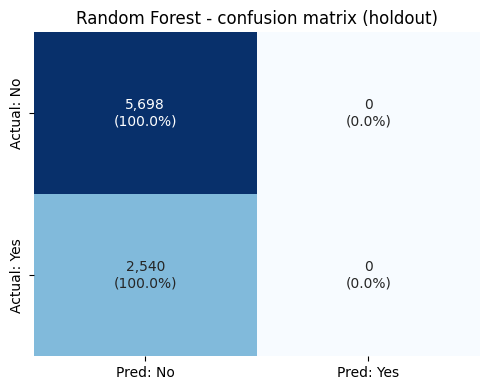

In [ ]:
from sklearn.metrics import confusion_matrix

model_name = "Random Forest"   # change the title here

cm = confusion_matrix(y_test, y_pred_rf)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100   # % of each true class

labels = np.array([[f"{cm[i, j]:,}\n({cm_pct[i, j]:.1f}%)" for j in range(2)]
                   for i in range(2)])

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Pred: No', 'Pred: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])
plt.title(f"{model_name} - confusion matrix (holdout)")
plt.tight_layout()
plt.show()

##XGBoost (Boosting Method):

Sequential Decision Trees used to correct past errors that are found. In a sense, creates a breeding pool of decision trees that will keep going until the errors stop shrinking/stagnate.

n_estimators: Specifies the number of trees to build; increasing it can improve performance but also increases training time and may lead to overfitting.

max_depth: Sets the maximum depth of each tree; shallower trees are more generalizable, while deeper trees can learn more complex patterns.

learning_rate: Controls how much each tree contributes to the final prediction; lower values usually require more trees but can produce a more robust model.


In [ ]:
import xgboost as xgb

xgbs = xgb.XGBClassifier( n_estimators=100, max_depth=6, learning_rate=0.1, objective='binary:logistic', random_state=42)

xgbs.fit(X_train_p, y_train)

y_pred_xgb=xgbs.predict(X_test_p)
y_proba_xgb = xgbs.predict_proba(X_test_p)

print("Accuracy:", (accuracy_score(y_test, y_pred_xgb)*100))

print("\nPrecision:", (precision_score(y_test, y_pred_xgb, zero_division=0)*100))

print("\nRecall:", (recall_score(y_test, y_pred_xgb, zero_division=0)*100))

print("\nF1 Score:", (f1_score(y_test, y_pred_xgb, zero_division=0)*100))

print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred_xgb))


print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb, zero_division=0))

Accuracy: 69.04588492352512

Precision: 47.8448275862069

Recall: 4.3700787401574805

F1 Score: 8.008658008658008
Confusion Matrix: 
 [[5577  121]
 [2429  111]]

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.98      0.81      5698
           1       0.48      0.04      0.08      2540

    accuracy                           0.69      8238
   macro avg       0.59      0.51      0.45      8238
weighted avg       0.63      0.69      0.59      8238



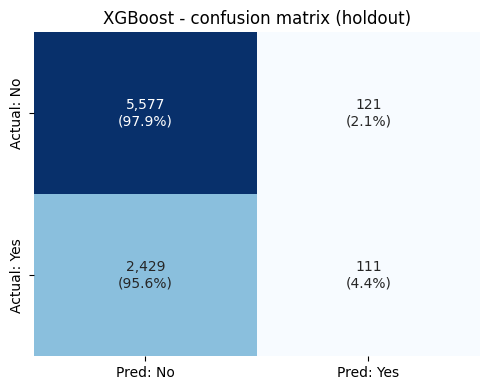

In [ ]:
from sklearn.metrics import confusion_matrix

model_name = "XGBoost"   # change the title here
cm = confusion_matrix(y_test, y_pred_xgb)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100   # % of each true class

labels = np.array([[f"{cm[i, j]:,}\n({cm_pct[i, j]:.1f}%)" for j in range(2)]
                   for i in range(2)])

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Pred: No', 'Pred: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])
plt.title(f"{model_name} - confusion matrix (holdout)")
plt.tight_layout()
plt.show()